4. Analyze Upvote and Downvote Data
Process: 
Analyzed the pattern : Calculated the overall upvote rate and ranked the individuals based on upvote to downvote ratio.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [24]:
def load_and_preprocess_data(file_path):
    try:
        df = pd.read_csv(file_path)
        df['created_at'] = pd.to_datetime(df['created_at'])
        df['comment'] = df['comment'].astype(str).str.lower()
        df['comment'] = df['comment'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None

In [25]:
def analyze_sentiment_and_performance(df):
    print("1. Overall User Sentiment\n")
    sentiment_counts = df['state'].value_counts()
    upvote_percentage = (sentiment_counts.get('UP', 0) / len(df)) * 100
    print(f"Overall Upvote Rate: {upvote_percentage:.2f}%\n")

    offer_performance = df.groupby('offer_id')['state'].apply(
        lambda x: (x == 'UP').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    print("2. Offer Performance\n")
    print("Top 5 Best Performing Offers (by Upvote Rate):")
    print(offer_performance.head(5))
    print("\nTop 5 Worst Performing Offers (by Upvote Rate):")
    print(offer_performance.tail(5))

In [26]:
def analyze_temporal_trends(df):
    print("\n3. Total Upvote vs. Downvote Counts\n")
    
    plt.figure(figsize=(8, 6))
    
    sentiment_counts = df['state'].value_counts()
    
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['skyblue', 'salmon'])
    
    plt.title('Total Upvote vs. Downvote Counts')
    plt.ylabel('Number of Votes')
    plt.xlabel('Vote Type')
    plt.show()

1. Overall User Sentiment

Overall Upvote Rate: 95.59%

2. Offer Performance

Top 5 Best Performing Offers (by Upvote Rate):
offer_id
5272      100.0
258424    100.0
231627    100.0
231754    100.0
232491    100.0
Name: state, dtype: float64

Top 5 Worst Performing Offers (by Upvote Rate):
offer_id
180794    0.0
257832    0.0
257830    0.0
225439    0.0
198355    0.0
Name: state, dtype: float64

3. Total Upvote vs. Downvote Counts



C:\Users\komal\AppData\Local\Temp\ipykernel_20248\3588479316.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['skyblue', 'salmon'])


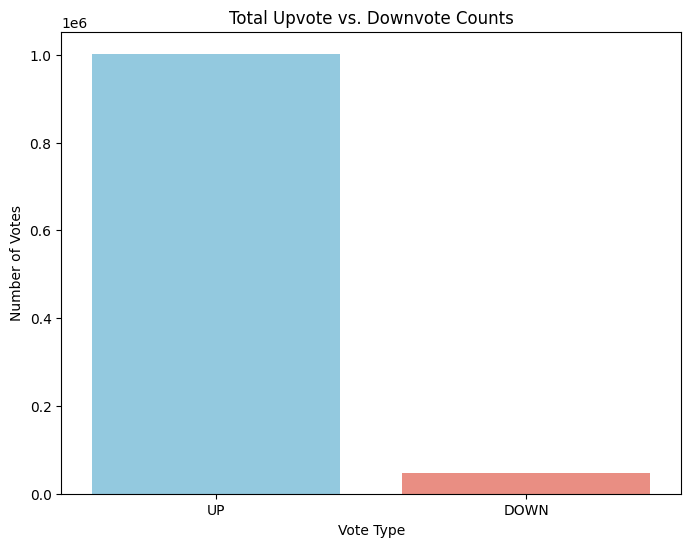

In [27]:
def main():
    file_path = '4_voting_data.csv'
    df = load_and_preprocess_data(file_path)
    if df is not None:
        analyze_sentiment_and_performance(df)
        analyze_temporal_trends(df)

if __name__ == "__main__":
    main()